# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/imnxr/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip install -q pandas numpy scikit-learn matplotlib duckdb huggingface_hub python-dotenv

Note: you may need to restart the kernel to use updated packages.


## 1. Question

*The research question and the decision it supports.*

### Research question

Can historical Google Search Console performance from the previous 30 days identify content pages likely to experience a substantial decline in impressions during the following 30 days for previously unseen clients?

### Decision supported

The analysis supports an editorial prioritization decision:

> Which content pages should SEO analysts review first for a possible refresh?

A substantial decline is defined as a reduction of more than 30% in impressions between the feature window and the following non-overlapping outcome window.

The intended output is a ranked screening list for human review, not an automatic decision that a page must be refreshed.

In [2]:
from dotenv import load_dotenv
import os
import getpass
import duckdb

load_dotenv()

# 1. Use the local .env file when running in VS Code
HF_TOKEN = os.getenv("HF_TOKEN")

# 2. Use Google Colab Secrets when running in Colab
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except (ImportError, KeyError, AttributeError):
        pass

# 3. Safely ask for a token when neither source is available
if not HF_TOKEN:
    HF_TOKEN = getpass.getpass(
        "Enter your Hugging Face token: "
    ).strip()

assert HF_TOKEN, "A Hugging Face token is required."

con = duckdb.connect()

con.execute("SET enable_http_metadata_cache = true")
con.execute("SET parquet_metadata_cache = true")
con.execute("SET http_retries = 1")
con.execute("SET http_retry_wait_ms = 1000")
con.execute("SET http_retry_backoff = 2")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"

print("Warehouse connection configured")

Warehouse connection configured


In [3]:
from pathlib import Path

temp_dir = Path("../../work/duckdb_temp").resolve()
temp_dir.mkdir(parents=True, exist_ok=True)

con.execute("SET memory_limit = '4GB'")
con.execute(f"SET temp_directory = '{temp_dir.as_posix()}'")
con.execute("SET threads = 2")

print("DuckDB temp directory:", temp_dir)
print("Memory limit: 4GB")
print("Threads: 2")

DuckDB temp directory: D:\Internship\flyrank-ml-internship\work\duckdb_temp
Memory limit: 4GB
Threads: 2


In [4]:
from pathlib import Path

cache_dir = Path("../../work/cache").resolve()
cache_dir.mkdir(parents=True, exist_ok=True)

model_base_cache = cache_dir / "capstone_model_base.parquet"

if model_base_cache.exists():
    model_base = con.sql(
        f"""
        SELECT *
        FROM read_parquet('{model_base_cache.as_posix()}')
        """
    ).df()

    print("Loaded model_base from local cache:", model_base.shape)

else:
    model_base = con.sql(
        f"""
        WITH daily AS (
            SELECT
                client_hash_id,
                content_hash_id,

                SUM(
                    CASE
                        WHEN report_date BETWEEN DATE '2026-03-03'
                                             AND DATE '2026-04-01'
                        THEN gsc_impressions
                        ELSE 0
                    END
                ) AS impressions_prev30,

                SUM(
                    CASE
                        WHEN report_date BETWEEN DATE '2026-03-03'
                                             AND DATE '2026-04-01'
                        THEN gsc_clicks
                        ELSE 0
                    END
                ) AS clicks_prev30,

                AVG(
                    CASE
                        WHEN report_date BETWEEN DATE '2026-03-03'
                                             AND DATE '2026-04-01'
                        THEN gsc_avg_position
                    END
                ) AS avg_position_prev30,

                SUM(
                    CASE
                        WHEN report_date BETWEEN DATE '2026-04-02'
                                             AND DATE '2026-05-01'
                        THEN gsc_impressions
                        ELSE 0
                    END
                ) AS impressions_future30

            FROM read_parquet(
                '{REL}/fact_content_daily_performance/**/*.parquet'
            )
            WHERE report_date BETWEEN DATE '2026-03-03'
                                  AND DATE '2026-05-01'
              AND gsc_data_available = TRUE
            GROUP BY 1, 2
        )

        SELECT *
        FROM daily
        WHERE impressions_prev30 >= 100
        """
    ).df()

    con.register("model_base_df", model_base)

    con.execute(
        f"""
        COPY model_base_df
        TO '{model_base_cache.as_posix()}'
        (FORMAT PARQUET)
        """
    )

    con.unregister("model_base_df")

    print("Downloaded and cached model_base:", model_base.shape)
    print("Cache saved to:", model_base_cache)

Loaded model_base from local cache: (101362, 6)


In [5]:
model_base["impression_change_ratio"] = (
    model_base["impressions_future30"]
    /
    model_base["impressions_prev30"]
)

model_base["decline_percent"] = (
    1 - model_base["impression_change_ratio"]
) * 100

model_base[[
    "impressions_prev30",
    "impressions_future30",
    "impression_change_ratio",
    "decline_percent"
]].describe()

,impressions_prev30,impressions_future30,impression_change_ratio,decline_percent
count,101362.000000,101362.000000,101362.000000,101362.000000
mean,2692.071092,2724.069079,1.153282,-15.328196
std,6833.591836,7585.892718,2.338236,233.823629
min,100.000000,0.000000,0.000000,-19811.851852
25%,280.000000,202.000000,0.500555,-20.191179
50%,771.000000,644.000000,0.791667,20.833333
75%,2459.000000,2284.000000,1.201912,49.944549
max,631482.000000,784319.000000,199.118519,100.000000


In [6]:
for threshold in [0.2, 0.3, 0.5]:
    label = (
        model_base["impression_change_ratio"] < (1 - threshold)
    )
    
    print(
        f"Decline > {int(threshold*100)}%:",
        label.sum(),
        "pages",
        round(label.mean()*100, 2),
        "%"
    )

Decline > 20%: 51326 pages 50.64 %
Decline > 30%: 42723 pages 42.15 %
Decline > 50%: 25222 pages 24.88 %


In [7]:
model_base["decline_label"] = (
    model_base["impression_change_ratio"] < 0.70
).astype(int)

print(model_base["decline_label"].value_counts())
print()
print(model_base["decline_label"].value_counts(normalize=True).round(3))


decline_label
0    58639
1    42723
Name: count, dtype: int64

decline_label
0    0.579
1    0.421
Name: proportion, dtype: float64


In [8]:
content_features = con.sql(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,
        content_created_date
    FROM read_parquet(
        '{REL}/dim_content.parquet'
    )
    """
).df()

print("Content feature shape:", content_features.shape)

assert not content_features.duplicated(
    ["client_hash_id", "content_hash_id"]
).any(), "Duplicate page keys found"

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content feature shape: (519606, 3)


In [9]:
duplicate_check = content_features.groupby(
    ["client_hash_id", "content_hash_id"]
).size()

print("Total rows:", len(content_features))
print("Unique page keys:", duplicate_check.shape[0])
print("Duplicate keys:", (duplicate_check > 1).sum())

Total rows: 519606
Unique page keys: 519606
Duplicate keys: 0


In [10]:
model_df = model_base.merge(
    content_features,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Shape:", model_df.shape)
print("\nMissing values:")
print(model_df.isna().sum().sort_values(ascending=False).head(10))


Shape: (101362, 10)

Missing values:
client_hash_id             0
content_hash_id            0
impressions_prev30         0
clicks_prev30              0
avg_position_prev30        0
impressions_future30       0
impression_change_ratio    0
decline_percent            0
decline_label              0
content_created_date       0
dtype: int64


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



This project uses the FlyRank ML Internship full warehouse release.

### Data sources

The analysis uses two public-safe warehouse tables:

- `fact_content_daily_performance`
  - Daily content-level search performance data.
  - Used to construct historical feature windows and future outcome windows.

- `dim_content`
  - Used only to retrieve `content_created_date`, from which `content_age_days` was calculated at the feature cutoff. 
    Other current-snapshot metadata was excluded because its historical value at the cutoff could not be verified, creating a risk of temporal leakage.

### Modeling unit

The unit of analysis is one content page identified by:

- `client_hash_id`
- `content_hash_id`

### Time windows

Features are created from:

**Feature window**
- 2026-03-03 to 2026-04-01

The future outcome is measured using:

**Outcome window**
- 2026-04-02 to 2026-05-01

The outcome window occurs after the feature window to prevent target leakage.

### Dataset construction

Pages were included when:
- GSC performance data was available.
- The page received at least 100 impressions during the feature window.

The resulting modeling dataset contains:

- 101,362 pages
- 44 clients

### Excluded data

The query-level snapshot table was not used as a predictive feature source because it represents a fixed period ending at the end of the warehouse release. Using these values for prediction would introduce future information leakage.

GA4-only features were not included in the initial model because availability differs between clients.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Target definition

The task was framed as binary classification at the page level. Each observation represents one content page identified by `client_hash_id` and `content_hash_id`.

The feature window covered **2026-03-03 through 2026-04-01**, and the non-overlapping outcome window covered **2026-04-02 through 2026-05-01**.

A page was labelled as declining when its total GSC impressions in the outcome window were more than 30% lower than in the feature window:

- `decline_label = 1` when `impressions_future30 / impressions_prev30 < 0.70`
- `decline_label = 0` otherwise

Pages were included only when GSC data were available and the feature window contained at least 100 impressions. The resulting modelling dataset contained **101,362 pages from 44 clients**. The positive class represented approximately 42.1% of observations.

### Temporal and leakage controls

Only information intended to be available by the feature cutoff was considered for final modelling.

The fixed 90-day query table was excluded because its window extended beyond the selected feature cutoff and would introduce future information. `last_optimized_date` was also excluded after an audit found that 37,893 rows contained optimization dates after 2026-04-01.

Other content metadata fields were excluded from the strict final models because the warehouse provided current snapshot values rather than confirmed historical values at the feature cutoff.

The final strict model features were:

- impressions during the previous 30 days
- clicks during the previous 30 days
- average search position during the previous 30 days
- content age in days at the feature cutoff

Outcome-derived fields, page identifiers, client identifiers, future impressions, change ratios, and decline percentages were not supplied as model features.

### Validation strategy

A grouped holdout split was performed using `client_hash_id`. This ensured that no client appeared in both training and testing data.

- Training: 94,325 pages from 35 clients
- Testing: 7,037 pages from 9 unseen clients

This design evaluates whether the approaches transfer to new clients rather than memorizing patterns belonging to clients already represented during training.

### Approaches compared

Three approaches were evaluated:

1. **Transparent baseline:** a weighted refresh-priority score based on previous impressions, average position, and click-through-rate proxy. Feature scaling and the classification threshold were fitted using training data only.
2. **Strict logistic regression:** median imputation, standard scaling, balanced class weights, and the four temporally aligned features.
3. **Strict random forest:** median imputation, balanced class weights, 200 trees, maximum depth of 12, and minimum leaf size of 20.

Performance was measured using accuracy, precision, recall, F1 score, ROC-AUC, and confusion matrices on the held-out unseen clients.

In [11]:
import pandas as pd
import numpy as np

In [12]:
# Prepare final modelling dataset

model_df = model_df.copy()

model_df["content_created_date"] = pd.to_datetime(
    model_df["content_created_date"]
)

model_df["content_age_days"] = (
    pd.Timestamp("2026-04-01")
    - model_df["content_created_date"]
).dt.days.clip(lower=0)

model_df[
    [
        "content_created_date",
        "content_age_days"
    ]
].head()

,content_created_date,content_age_days
0,2025-07-15,260
1,2025-07-15,260
2,2025-07-16,259
3,2025-07-16,259
4,2025-07-16,259


In [13]:
# Define leakage-safe target and features

target = "decline_label"

feature_columns = [
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_prev30",
    "content_age_days"
]

X = model_df[feature_columns].copy()
y = model_df[target].copy()

print("Features:", X.shape)
print("Target:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print()
print(y.value_counts(normalize=True).round(3))

Features: (101362, 4)
Target: (101362,)

Target distribution:
decline_label
0    58639
1    42723
Name: count, dtype: int64

decline_label
0    0.579
1    0.421
Name: proportion, dtype: float64


In [14]:
from sklearn.model_selection import GroupShuffleSplit

groups = model_df["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain clients:", model_df.iloc[train_idx]["client_hash_id"].nunique())
print("Test clients:", model_df.iloc[test_idx]["client_hash_id"].nunique())

Train shape: (94325, 4)
Test shape: (7037, 4)

Train clients: 35
Test clients: 9


In [15]:
# Transparent baseline refresh priority score

baseline_df = model_df.copy()

baseline_df["ctr_proxy"] = (
    baseline_df["clicks_prev30"]
    /
    baseline_df["impressions_prev30"]
)

baseline_df["baseline_score"] = (
    baseline_df["impressions_prev30"].rank(pct=True) * 0.4
    +
    baseline_df["avg_position_prev30"].rank(pct=True) * 0.3
    +
    (1 - baseline_df["ctr_proxy"].rank(pct=True)) * 0.3
)

baseline_df[
    [
        "content_hash_id",
        "baseline_score",
        "decline_label"
    ]
].head()

,content_hash_id,baseline_score,decline_label
0,content_a590818571b5f841,0.461657,0
1,content_8a30c12d0c0b2e50,0.227620,1
2,content_a5320eb18368e3e3,0.391614,1
3,content_8bd238520b53b1b0,0.173220,1
4,content_5b0d33094decc845,0.288880,1


In [16]:
from sklearn.preprocessing import MinMaxScaler

baseline_features = model_df[
    ["impressions_prev30", "avg_position_prev30", "clicks_prev30"]
].copy()

baseline_features["ctr_proxy"] = (
    baseline_features["clicks_prev30"]
    / baseline_features["impressions_prev30"]
).fillna(0)

baseline_train = baseline_features.iloc[train_idx].copy()
baseline_test = baseline_features.iloc[test_idx].copy()

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    baseline_train[
        ["impressions_prev30", "avg_position_prev30", "ctr_proxy"]
    ]
)

test_scaled = scaler.transform(
    baseline_test[
        ["impressions_prev30", "avg_position_prev30", "ctr_proxy"]
    ]
)

baseline_train_score = (
    0.4 * train_scaled[:, 0]
    + 0.3 * train_scaled[:, 1]
    + 0.3 * (1 - train_scaled[:, 2])
)

baseline_test_score = (
    0.4 * test_scaled[:, 0]
    + 0.3 * test_scaled[:, 1]
    + 0.3 * (1 - test_scaled[:, 2])
)

print("Train baseline scores:", baseline_train_score.shape)
print("Test baseline scores:", baseline_test_score.shape)
print("Test score range:", baseline_test_score.min(), baseline_test_score.max())

Train baseline scores: (94325,)
Test baseline scores: (7037,)
Test score range: 0.1520622728266339 0.5920293302484181


In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_train,
    baseline_train_score
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-12)
)

best_index = np.argmax(f1_scores)
baseline_threshold = thresholds[best_index]

print("Baseline threshold:", round(float(baseline_threshold), 4))
print("Training F1 at threshold:", round(float(f1_scores[best_index]), 4))

Baseline threshold: 0.2972
Training F1 at threshold: 0.5939


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

baseline_test_pred = (
    baseline_test_score >= baseline_threshold
).astype(int)

baseline_metrics = {
    "accuracy": accuracy_score(y_test, baseline_test_pred),
    "precision": precision_score(y_test, baseline_test_pred),
    "recall": recall_score(y_test, baseline_test_pred),
    "f1": f1_score(y_test, baseline_test_pred),
    "roc_auc": roc_auc_score(y_test, baseline_test_score)
}

print("Baseline metrics on unseen clients:")
for name, value in baseline_metrics.items():
    print(f"{name}: {value:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, baseline_test_pred))

Baseline metrics on unseen clients:
accuracy: 0.5232
precision: 0.4908
recall: 0.9645
f1: 0.6506
roc_auc: 0.6787

Confusion matrix:
[[ 559 3240]
 [ 115 3123]]


In [19]:
feature_cutoff = pd.Timestamp("2026-04-01")

date_audit = pd.Series({
    "total_rows": len(model_df),
    "created_date_missing":
        model_df["content_created_date"].isna().sum(),
    "created_after_cutoff":
        (model_df["content_created_date"] > feature_cutoff).sum()
})

print(date_audit)

print("\nLatest content creation date:")
print(model_df["content_created_date"].max())

total_rows              101362
created_date_missing         0
created_after_cutoff         0
dtype: int64

Latest content creation date:
2026-03-31 00:00:00


In [20]:
feature_columns = [
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_prev30",
    "content_age_days"
]

X = model_df[feature_columns].copy()
y = model_df["decline_label"].copy()

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Updated train shape:", X_train.shape)
print("Updated test shape:", X_test.shape)
print("Features:", feature_columns)

Updated train shape: (94325, 4)
Updated test shape: (7037, 4)
Features: ['impressions_prev30', 'clicks_prev30', 'avg_position_prev30', 'content_age_days']


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [22]:
strict_feature_columns = [
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_prev30",
    "content_age_days"
]

strict_numeric_features = strict_feature_columns
strict_categorical_features = []

X_strict = model_df[strict_feature_columns]

X_train_strict = X_strict.iloc[train_idx]
X_test_strict = X_strict.iloc[test_idx]

print("Strict train shape:", X_train_strict.shape)
print("Strict test shape:", X_test_strict.shape)
print("Strict features:", strict_feature_columns)

Strict train shape: (94325, 4)
Strict test shape: (7037, 4)
Strict features: ['impressions_prev30', 'clicks_prev30', 'avg_position_prev30', 'content_age_days']


In [23]:
strict_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

strict_logistic_model = Pipeline(
    steps=[
        ("preprocessor", strict_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

strict_random_forest_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

strict_logistic_model.fit(X_train_strict, y_train)
strict_random_forest_model.fit(X_train_strict, y_train)

print("Strict temporal models trained")

Strict temporal models trained


In [24]:
strict_logistic_score = strict_logistic_model.predict_proba(
    X_test_strict
)[:, 1]
strict_logistic_pred = strict_logistic_model.predict(
    X_test_strict
)

strict_random_forest_score = strict_random_forest_model.predict_proba(
    X_test_strict
)[:, 1]
strict_random_forest_pred = strict_random_forest_model.predict(
    X_test_strict
)

strict_logistic_metrics = {
    "accuracy": accuracy_score(y_test, strict_logistic_pred),
    "precision": precision_score(y_test, strict_logistic_pred),
    "recall": recall_score(y_test, strict_logistic_pred),
    "f1": f1_score(y_test, strict_logistic_pred),
    "roc_auc": roc_auc_score(y_test, strict_logistic_score)
}

strict_random_forest_metrics = {
    "accuracy": accuracy_score(y_test, strict_random_forest_pred),
    "precision": precision_score(y_test, strict_random_forest_pred),
    "recall": recall_score(y_test, strict_random_forest_pred),
    "f1": f1_score(y_test, strict_random_forest_pred),
    "roc_auc": roc_auc_score(y_test, strict_random_forest_score)
}

print("Strict logistic regression:")
for name, value in strict_logistic_metrics.items():
    print(f"{name}: {value:.4f}")

print("\nStrict random forest:")
for name, value in strict_random_forest_metrics.items():
    print(f"{name}: {value:.4f}")

Strict logistic regression:
accuracy: 0.4687
precision: 0.4510
recall: 0.7125
f1: 0.5524
roc_auc: 0.4667

Strict random forest:
accuracy: 0.4854
precision: 0.4206
recall: 0.3132
f1: 0.3590
roc_auc: 0.5264


In [25]:
final_results_df = pd.DataFrame(
    [
        {
            "model": "Transparent baseline",
            **baseline_metrics
        },
        {
            "model": "Strict logistic regression",
            **strict_logistic_metrics
        },
        {
            "model": "Strict random forest",
            **strict_random_forest_metrics
        }
    ]
)

final_results_df = final_results_df[
    ["model", "accuracy", "precision", "recall", "f1", "roc_auc"]
].sort_values("roc_auc", ascending=False)

final_results_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,Transparent baseline,0.5232,0.4908,0.9645,0.6506,0.6787
2,Strict random forest,0.4854,0.4206,0.3132,0.3590,0.5264
1,Strict logistic regression,0.4687,0.4510,0.7125,0.5524,0.4667


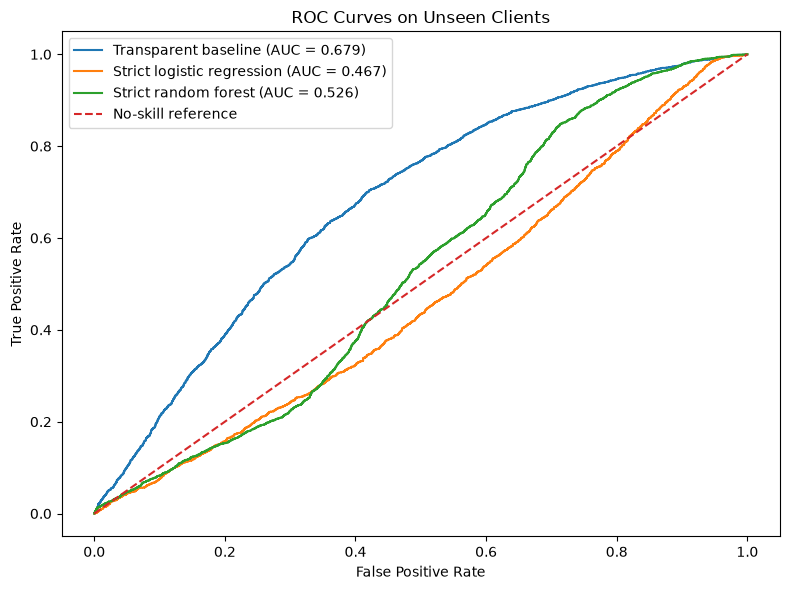

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_test_score
)

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    strict_logistic_score
)

forest_fpr, forest_tpr, _ = roc_curve(
    y_test,
    strict_random_forest_score
)

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Transparent baseline (AUC = {baseline_metrics['roc_auc']:.3f})"
)

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Strict logistic regression (AUC = {strict_logistic_metrics['roc_auc']:.3f})"
)

plt.plot(
    forest_fpr,
    forest_tpr,
    label=f"Strict random forest (AUC = {strict_random_forest_metrics['roc_auc']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="No-skill reference"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Unseen Clients")
plt.legend()
plt.tight_layout()
plt.show()

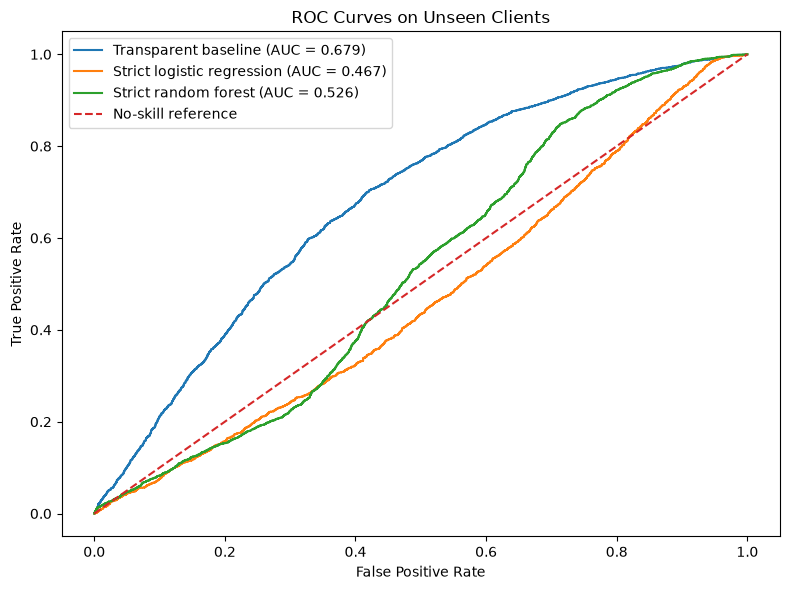

Saved to: D:\Internship\flyrank-ml-internship\work\outputs\figures\capstone_roc_unseen_clients.png


In [27]:
from pathlib import Path

figures_dir = Path("../../work/outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

roc_path = figures_dir / "capstone_roc_unseen_clients.png"

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Transparent baseline (AUC = {baseline_metrics['roc_auc']:.3f})"
)

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Strict logistic regression (AUC = {strict_logistic_metrics['roc_auc']:.3f})"
)

plt.plot(
    forest_fpr,
    forest_tpr,
    label=f"Strict random forest (AUC = {strict_random_forest_metrics['roc_auc']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="No-skill reference"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Unseen Clients")
plt.legend()
plt.tight_layout()

plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", roc_path.resolve())

In [28]:
outputs_dir = Path("../../work/outputs")
outputs_dir.mkdir(parents=True, exist_ok=True)

results_path = outputs_dir / "capstone_model_comparison.csv"

final_results_df.to_csv(results_path, index=False)

print("Saved to:", results_path.resolve())

Saved to: D:\Internship\flyrank-ml-internship\work\outputs\capstone_model_comparison.csv


In [29]:
recommendations_df = model_df.iloc[test_idx][
    [
        "client_hash_id",
        "content_hash_id",
        "impressions_prev30",
        "clicks_prev30",
        "avg_position_prev30",
        "impressions_future30",
        "decline_label"
    ]
].copy()

recommendations_df["refresh_priority_score"] = baseline_test_score

recommendations_df["recommended_for_refresh"] = (
    recommendations_df["refresh_priority_score"] >= baseline_threshold
).astype(int)

recommendations_df = recommendations_df.sort_values(
    "refresh_priority_score",
    ascending=False
).reset_index(drop=True)

print("Recommendations:", recommendations_df.shape)
print(
    recommendations_df[
        [
            "client_hash_id",
            "content_hash_id",
            "refresh_priority_score",
            "recommended_for_refresh"
        ]
    ].head(10)
)

Recommendations: (7037, 9)
            client_hash_id           content_hash_id  refresh_priority_score  \
0  client_f623b01661d4bfe4  content_92e1621a39268a5d                0.592029   
1  client_f623b01661d4bfe4  content_1ac77c540d858c13                0.588973   
2  client_f623b01661d4bfe4  content_ec882c9a213fcfac                0.584653   
3  client_9958f0a7ae1df715  content_565292e81fd43577                0.584418   
4  client_f623b01661d4bfe4  content_0e00aae179afced4                0.582356   
5  client_f623b01661d4bfe4  content_a0d5d6cc43258a12                0.581851   
6  client_3f0ce4d44fe94f3d  content_ba430e4aead0c09b                0.581556   
7  client_2094c6eb080311d5  content_5013a6e0fd154c75                0.575344   
8  client_9958f0a7ae1df715  content_37b1eaf53c4201c2                0.575116   
9  client_f623b01661d4bfe4  content_cbfbf4446b114a97                0.571842   

   recommended_for_refresh  
0                        1  
1                        1  
2    

In [30]:
recommendations_path = (
    outputs_dir / "capstone_refresh_recommendations.csv"
)

recommendations_df.to_csv(
    recommendations_path,
    index=False
)

print("Saved to:", recommendations_path.resolve())

Saved to: D:\Internship\flyrank-ml-internship\work\outputs\capstone_refresh_recommendations.csv


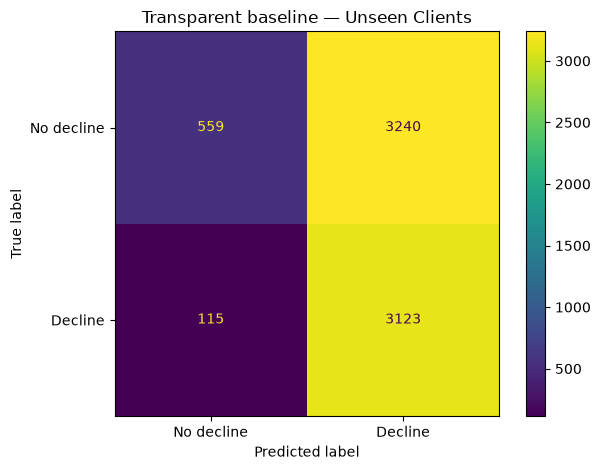

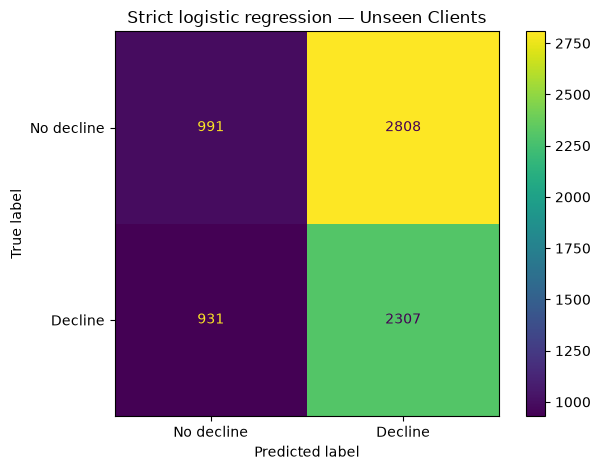

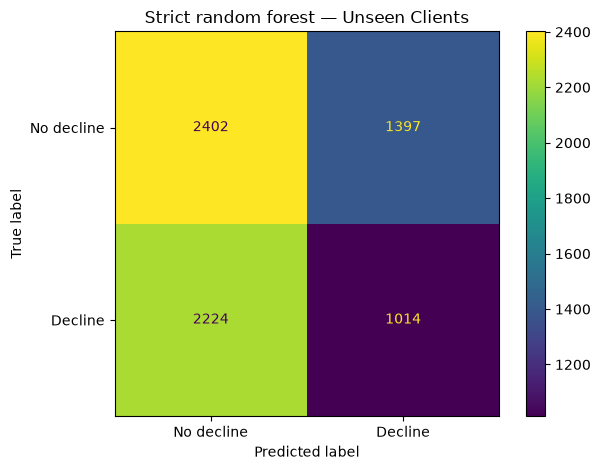

Saved confusion matrices:
D:\Internship\flyrank-ml-internship\work\outputs\figures\capstone_confusion_baseline.png
D:\Internship\flyrank-ml-internship\work\outputs\figures\capstone_confusion_logistic.png
D:\Internship\flyrank-ml-internship\work\outputs\figures\capstone_confusion_random_forest.png


In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

confusion_models = {
    "Transparent baseline": (
        baseline_test_pred,
        "capstone_confusion_baseline.png"
    ),
    "Strict logistic regression": (
        strict_logistic_pred,
        "capstone_confusion_logistic.png"
    ),
    "Strict random forest": (
        strict_random_forest_pred,
        "capstone_confusion_random_forest.png"
    )
}

saved_confusion_paths = []

for model_name, (predictions, filename) in confusion_models.items():
    figure_path = figures_dir / filename

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["No decline", "Decline"],
        values_format="d"
    )

    plt.title(f"{model_name} — Unseen Clients")
    plt.tight_layout()
    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    saved_confusion_paths.append(figure_path.resolve())

print("Saved confusion matrices:")
for path in saved_confusion_paths:
    print(path)

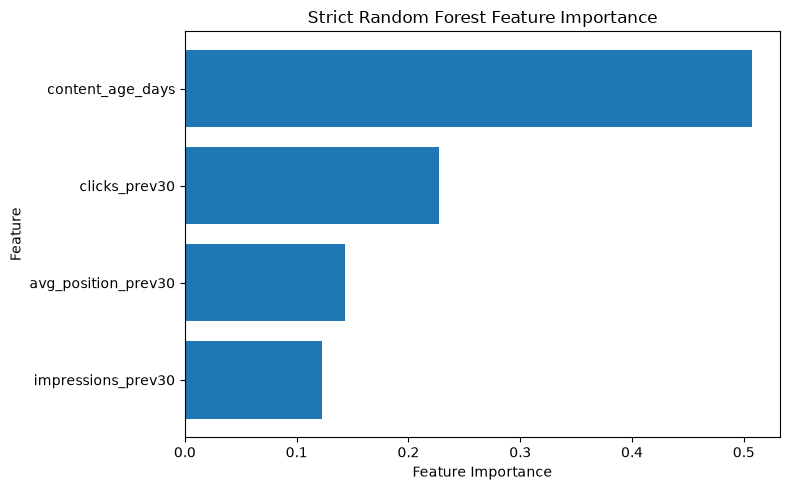

               feature  importance
0     content_age_days      0.5071
1        clicks_prev30      0.2271
2  avg_position_prev30      0.1432
3   impressions_prev30      0.1226

Saved to: D:\Internship\flyrank-ml-internship\work\outputs\figures\capstone_random_forest_feature_importance.png


In [32]:
rf_importance_df = pd.DataFrame({
    "feature": strict_feature_columns,
    "importance": strict_random_forest_model
        .named_steps["classifier"]
        .feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

importance_path = (
    figures_dir / "capstone_random_forest_feature_importance.png"
)

plt.figure(figsize=(8, 5))
plt.barh(
    rf_importance_df["feature"][::-1],
    rf_importance_df["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Strict Random Forest Feature Importance")
plt.tight_layout()

plt.savefig(
    importance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(rf_importance_df.round(4))
print("\nSaved to:", importance_path.resolve())

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Performance on unseen clients

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Transparent baseline | 0.5232 | 0.4908 | 0.9645 | 0.6506 | 0.6787 |
| Strict random forest | 0.4854 | 0.4206 | 0.3132 | 0.3590 | 0.5264 |
| Strict logistic regression | 0.4687 | 0.4510 | 0.7125 | 0.5524 | 0.4667 |

The transparent rule-based baseline achieved the strongest ranking performance, with a ROC-AUC of 0.6787 and an F1 score of 0.6506. Its recall of 0.9645 means that it identified 3,123 of the 3,238 declining pages in the unseen-client test set. However, it also produced 3,240 false positives, showing that the rule is suitable for broad screening rather than precise automatic decision-making.

The strict random forest achieved a ROC-AUC of 0.5264, only slightly above random ranking. Its recall was 0.3132, meaning that it missed most declining pages and did not generalize strongly to unseen clients.

The strict logistic regression achieved a ROC-AUC of 0.4667. Although its recall was 0.7125, its ranking performance below 0.50 indicates that relationships learned from the training clients did not transfer reliably to the held-out clients.

Overall, the transparent baseline performed better than both learned models. This result suggests that the available temporally safe features contain limited transferable signal across clients. The final recommendation list should therefore be treated as a human-review screening tool rather than an automated prediction system.

## 5. Limitations

*What this work cannot claim.*

### Limitations

This analysis has several important limitations.

First, the target represents decline during one specific 30-day outcome window. Performance may differ across seasons, industries, search-engine updates, and alternative feature or outcome periods.

Second, the 30% decline threshold is a modelling choice rather than a universal business definition. Pages close to the threshold may receive different labels despite having similar performance changes. Future work should test sensitivity to alternative thresholds such as 20% and 50%.

Third, evaluation used one grouped holdout split containing nine unseen clients. Although this is more realistic than a random page-level split, results may depend on which clients were selected. Repeated grouped validation across several client splits would provide a more stable estimate.

Fourth, the transparent baseline threshold was selected to maximize F1 on the training set. It may require recalibration when applied to new clients or when editorial capacity and the cost of false positives change.

Fifth, several potentially useful content attributes were available only as current warehouse snapshots. Because their historical values at the feature cutoff could not be verified, they were excluded from the strict final models to avoid temporal leakage.

Sixth, pages belonging to the same client may share topics, templates, strategies, and market conditions. The grouped split prevents direct client overlap, but substantial differences between clients can still limit cross-client generalization.

Finally, the analysis is predictive rather than causal. A page receiving a high refresh-priority score does not prove that refreshing it will improve impressions. The recommendations should be reviewed by domain experts and validated through controlled post-refresh measurement.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [33]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

recommendations_path = Path(
    "../../work/outputs/capstone_refresh_recommendations.csv"
)

recommendations_df = pd.read_csv(recommendations_path)

recommended_count = int(
    recommendations_df["recommended_for_refresh"].sum()
)

recommendation_rate = (
    recommended_count / len(recommendations_df)
)

display(Markdown("### Refresh-priority summary"))

print(f"Total evaluated pages: {len(recommendations_df):,}")
print(f"Pages flagged for review: {recommended_count:,}")
print(f"Flagged percentage: {recommendation_rate:.1%}")

display(Markdown("### Top 20 pages for editorial review"))

display(
    recommendations_df[
        [
            "client_hash_id",
            "content_hash_id",
            "impressions_prev30",
            "clicks_prev30",
            "avg_position_prev30",
            "refresh_priority_score",
            "recommended_for_refresh"
        ]
    ].head(20).round(4)
)

### Refresh-priority summary

Total evaluated pages: 7,037
Pages flagged for review: 6,363
Flagged percentage: 90.4%


### Top 20 pages for editorial review

,client_hash_id,content_hash_id,impressions_prev30,clicks_prev30,avg_position_prev30,refresh_priority_score,recommended_for_refresh
0,client_f623b01661d4bfe4,content_92e1621a39268a5d,127.0,0.0,90.2836,0.5920,1
1,client_f623b01661d4bfe4,content_1ac77c540d858c13,122.0,0.0,89.3397,0.5890,1
2,client_f623b01661d4bfe4,content_ec882c9a213fcfac,230.0,0.0,87.9827,0.5847,1
3,client_9958f0a7ae1df715,content_565292e81fd43577,848.0,0.0,87.7890,0.5844,1
4,client_f623b01661d4bfe4,content_0e00aae179afced4,174.0,1.0,90.8296,0.5824,1
5,client_f623b01661d4bfe4,content_a0d5d6cc43258a12,188.0,0.0,87.1248,0.5819,1
6,client_3f0ce4d44fe94f3d,content_ba430e4aead0c09b,138.0,0.0,87.0433,0.5816,1
7,client_2094c6eb080311d5,content_5013a6e0fd154c75,131.0,0.0,85.1242,0.5753,1
8,client_9958f0a7ae1df715,content_37b1eaf53c4201c2,121.0,0.0,85.0557,0.5751,1
9,client_f623b01661d4bfe4,content_cbfbf4446b114a97,145.0,0.0,84.0388,0.5718,1


## 7. Conclusion

This capstone investigated whether historical search-performance data could identify content pages likely to experience a substantial decline in impressions during a subsequent 30-day window.

The analysis used 101,362 eligible pages from 44 clients. Models were trained on 94,325 pages from 35 clients and evaluated on 7,037 pages from nine unseen clients.

The transparent refresh-priority baseline performed best, achieving a ROC-AUC of 0.6787 and an F1 score of 0.6506. Its recall of 0.9645 identified nearly all declining pages, although its precision of 0.4908 produced many false positives.

The strict logistic regression and random forest did not outperform the transparent baseline. This indicates that the learned relationships did not transfer reliably across unseen clients using the available temporally aligned features.

The final output is therefore a ranked screening system rather than an automatic refresh decision system. SEO analysts should use the recommendations to prioritize manual review, while confirming content quality, search intent, competition, and business value before refreshing a page.

Overall, the project demonstrates that a simple, transparent rule can provide more practical cross-client value than more complex machine-learning models when historical features are limited and client-specific variation is strong.

## 8. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Generated artifacts

The following tables and figures were produced for the capstone analysis and can be embedded in the final report or deployed project page:

- `../../work/outputs/capstone_model_comparison.csv`  
  Evaluation metrics for the transparent baseline, strict logistic regression, and strict random forest.

- `../../work/outputs/capstone_refresh_recommendations.csv`  
  Ranked refresh-priority recommendations for 7,037 pages from nine unseen clients.

- `../../work/outputs/figures/capstone_roc_unseen_clients.png`  
  ROC curves comparing all three approaches on unseen clients.

- `../../work/outputs/figures/capstone_confusion_baseline.png`  
  Confusion matrix for the transparent baseline.

- `../../work/outputs/figures/capstone_confusion_logistic.png`  
  Confusion matrix for strict logistic regression.

- `../../work/outputs/figures/capstone_confusion_random_forest.png`  
  Confusion matrix for the strict random forest.

- `../../work/outputs/figures/capstone_random_forest_feature_importance.png`  
  Feature-importance chart for the strict random forest.

### Final model comparison

,model,accuracy,precision,recall,f1,roc_auc
0,Transparent baseline,0.5232,0.4908,0.9645,0.6506,0.6787
1,Strict random forest,0.4854,0.4206,0.3132,0.3590,0.5264
2,Strict logistic regression,0.4687,0.4510,0.7125,0.5524,0.4667


### ROC curves on unseen clients

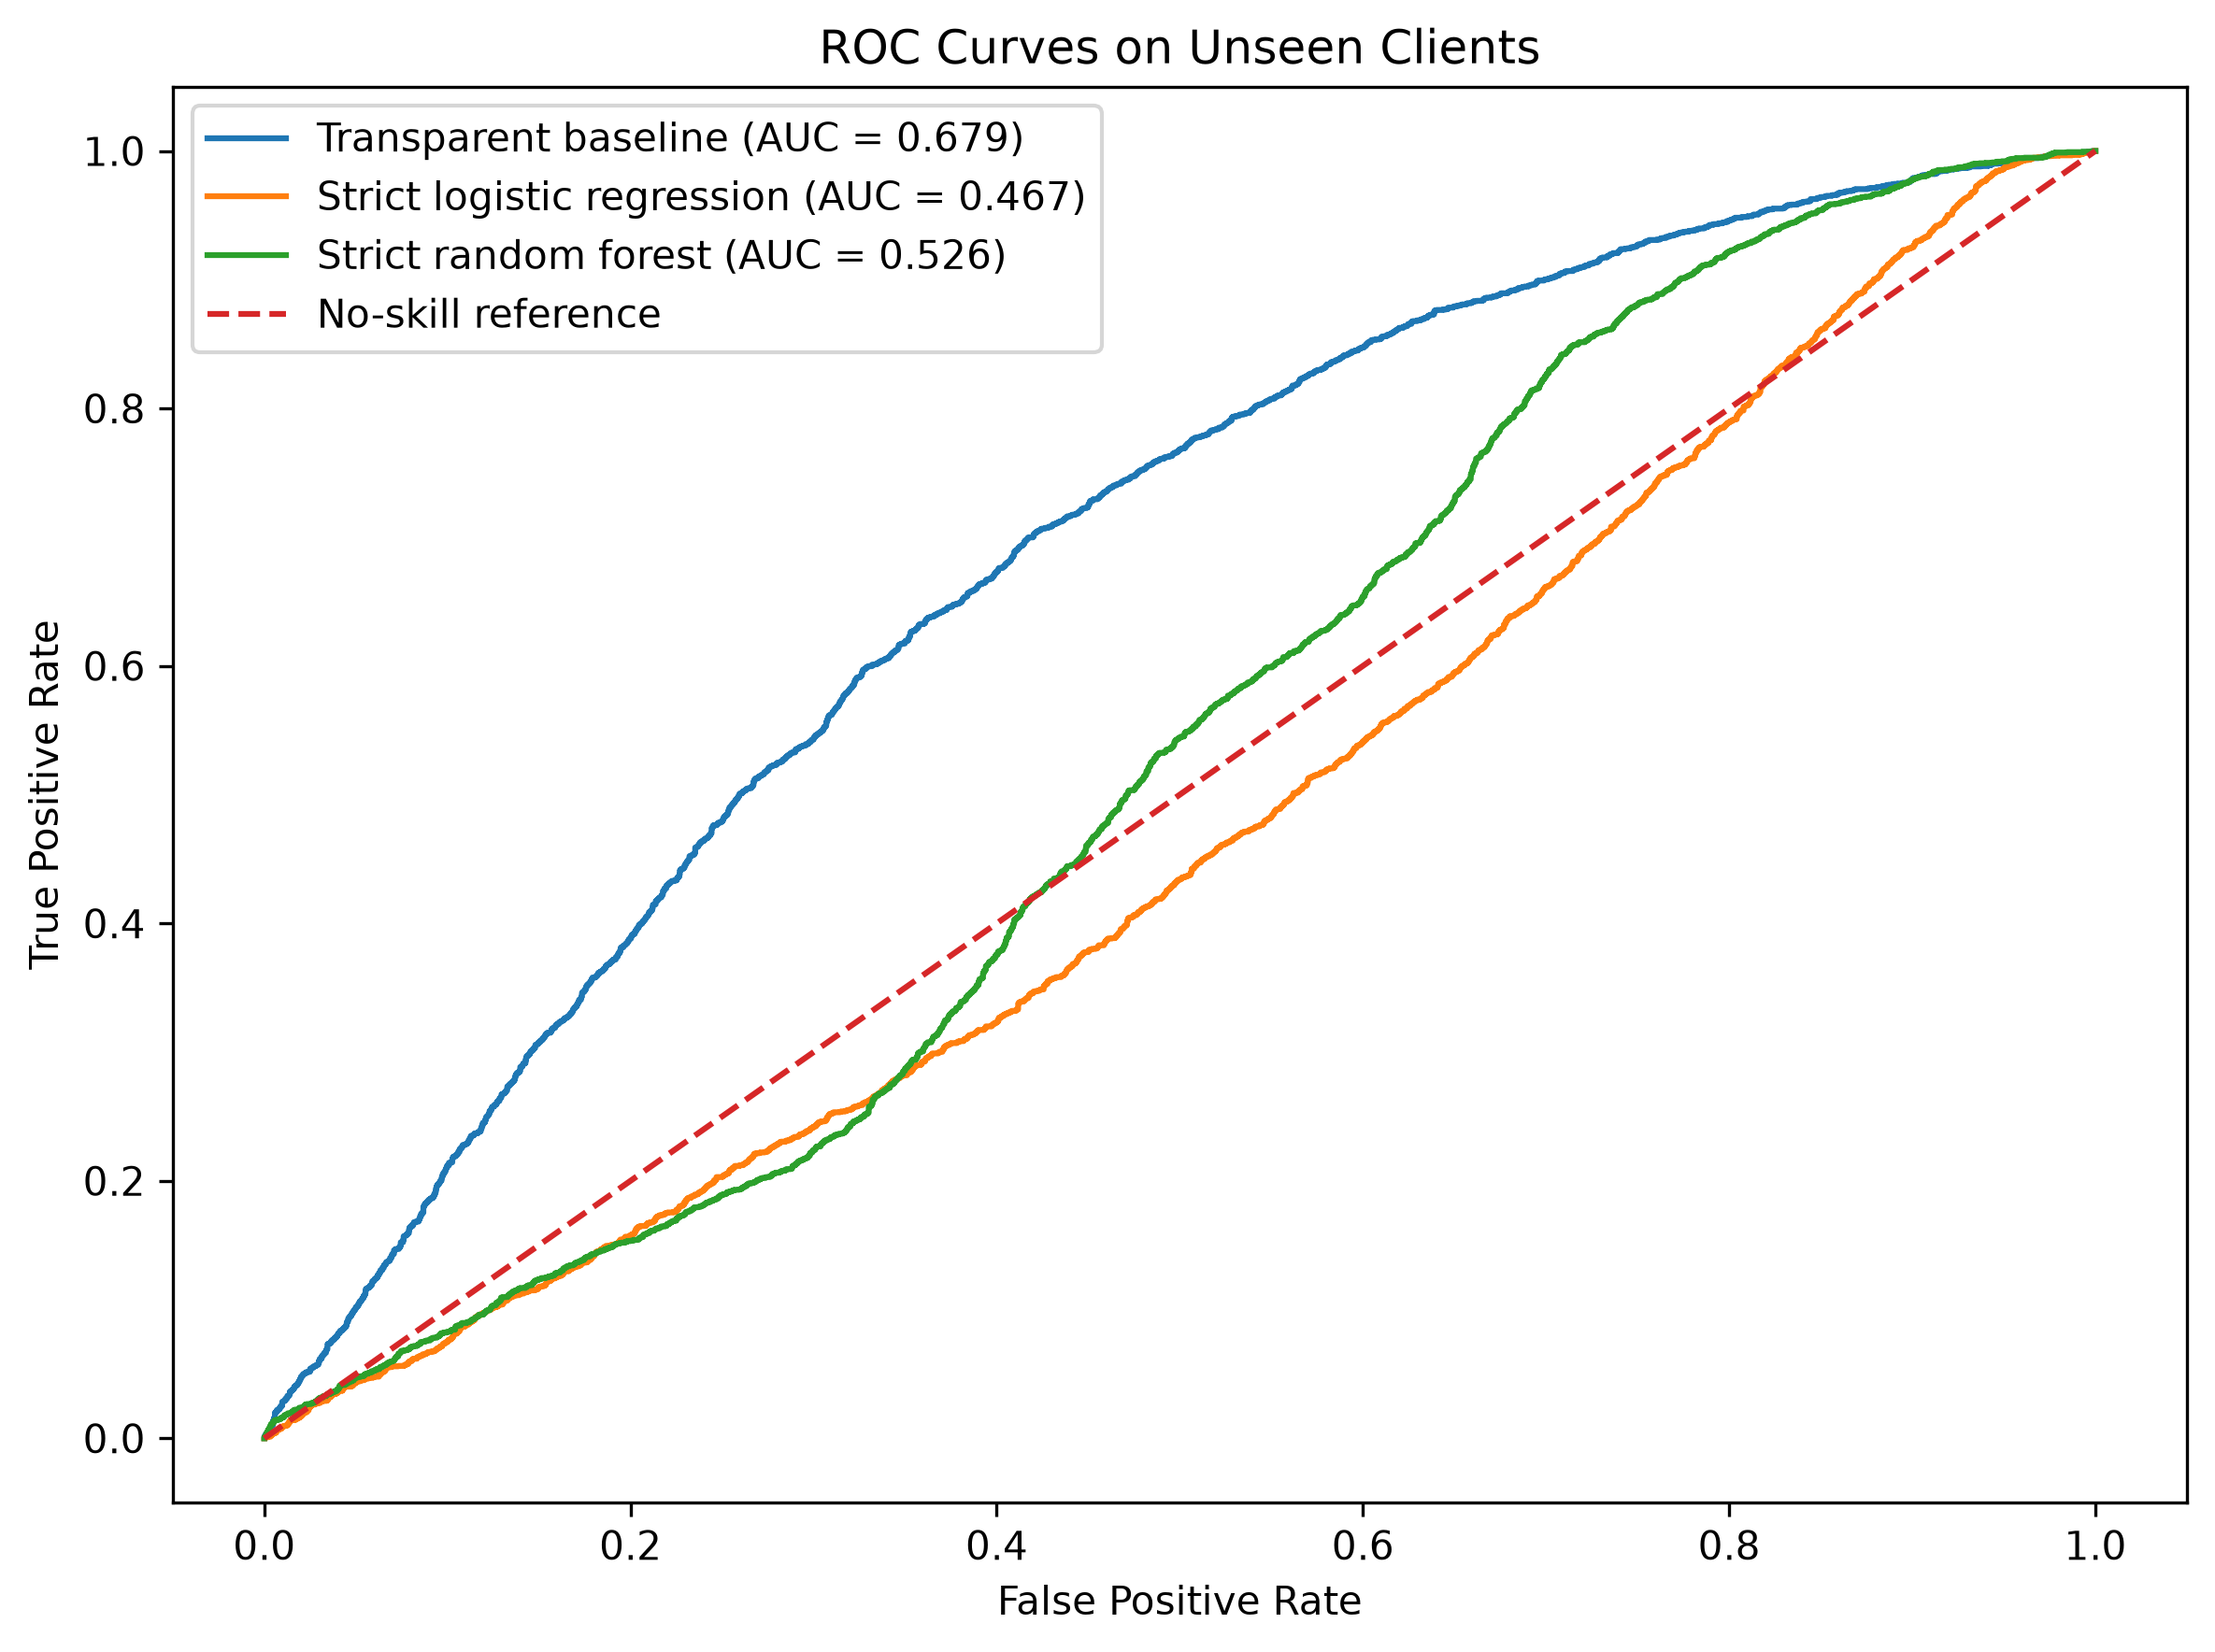

### Transparent baseline confusion matrix

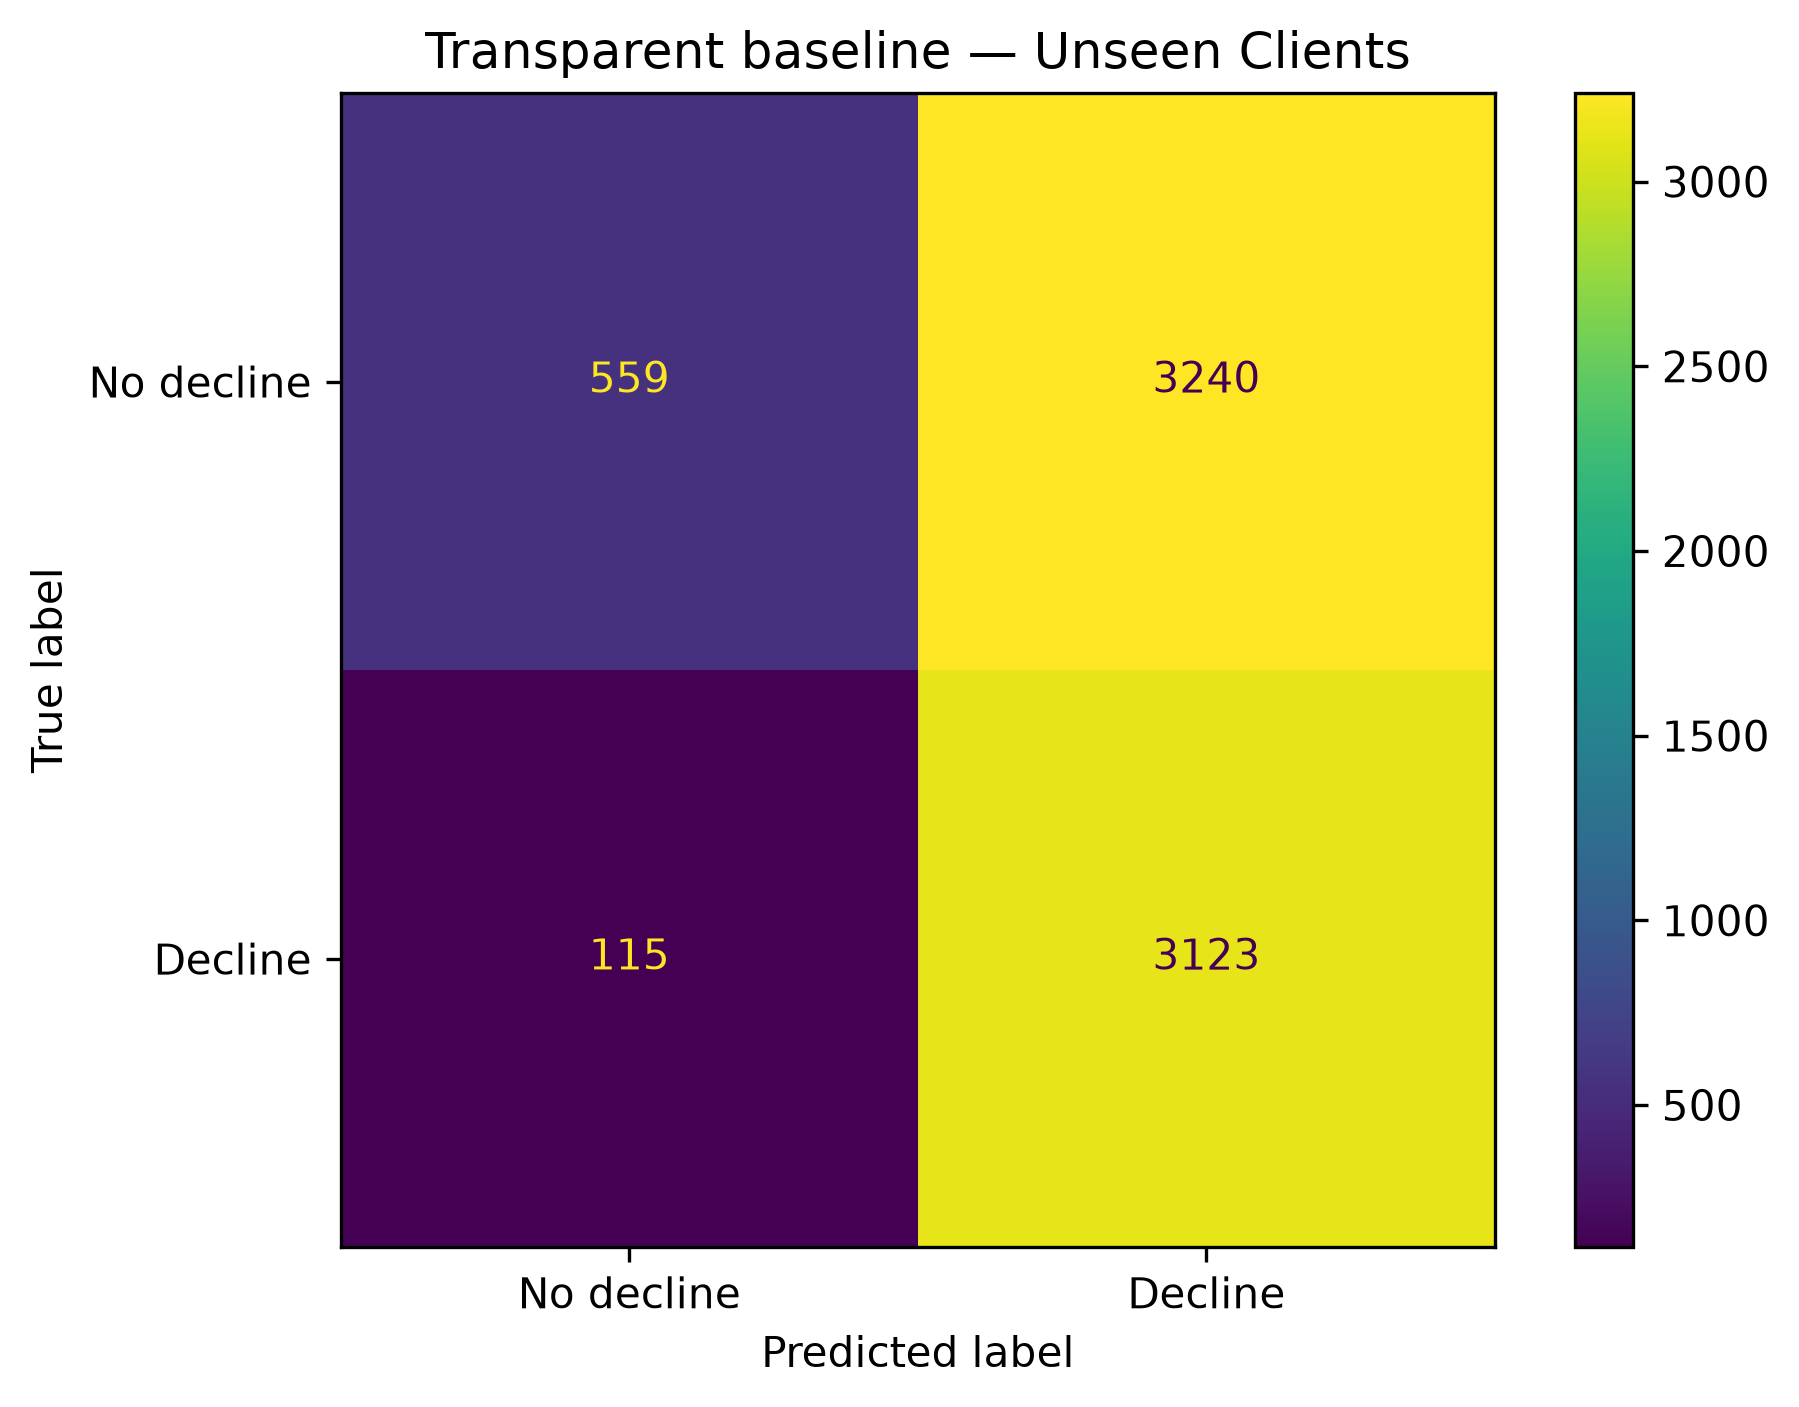

### Strict logistic regression confusion matrix

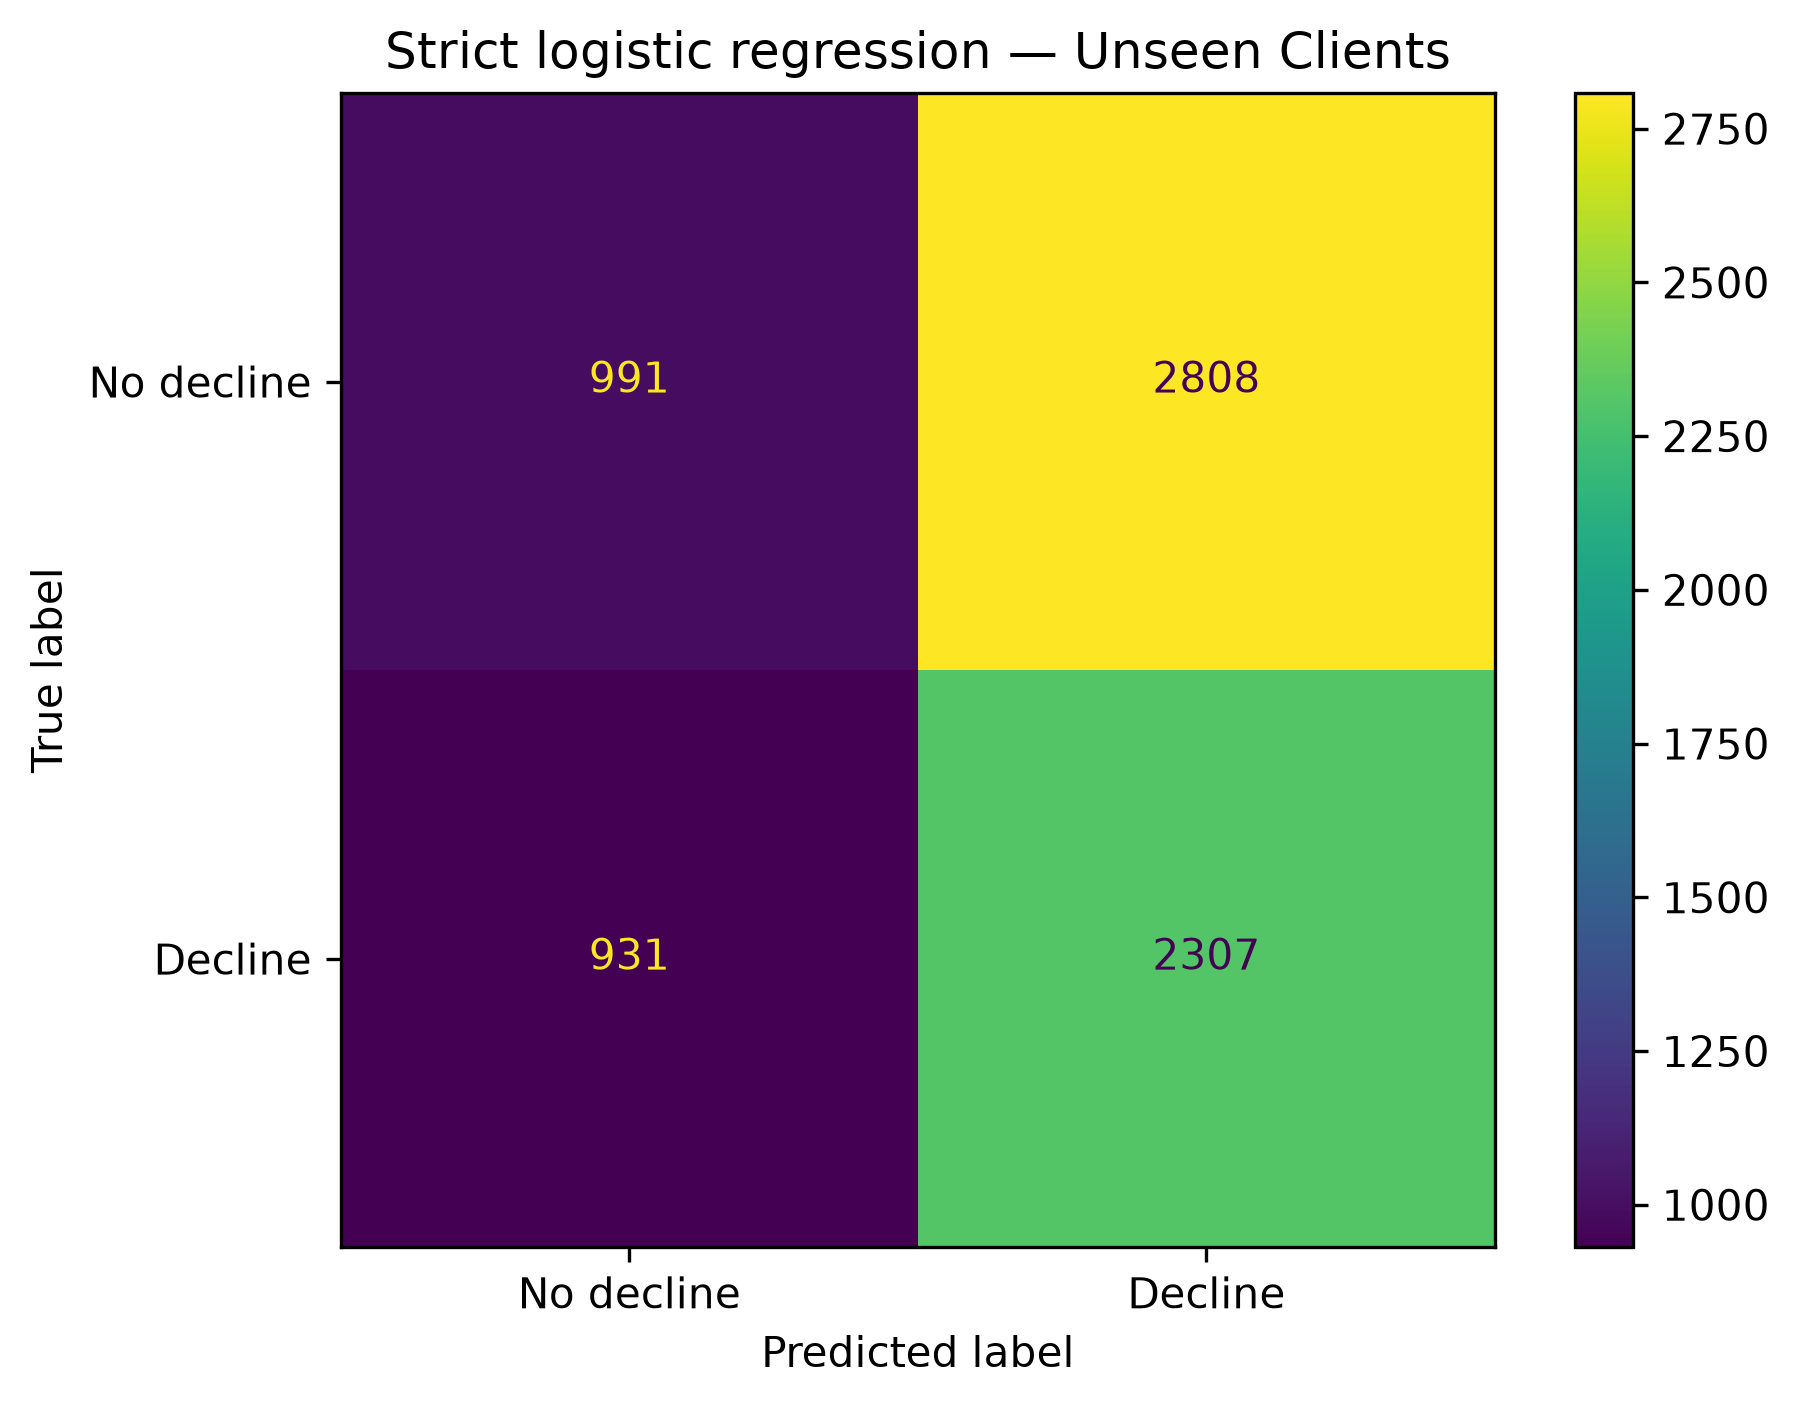

### Strict random forest confusion matrix

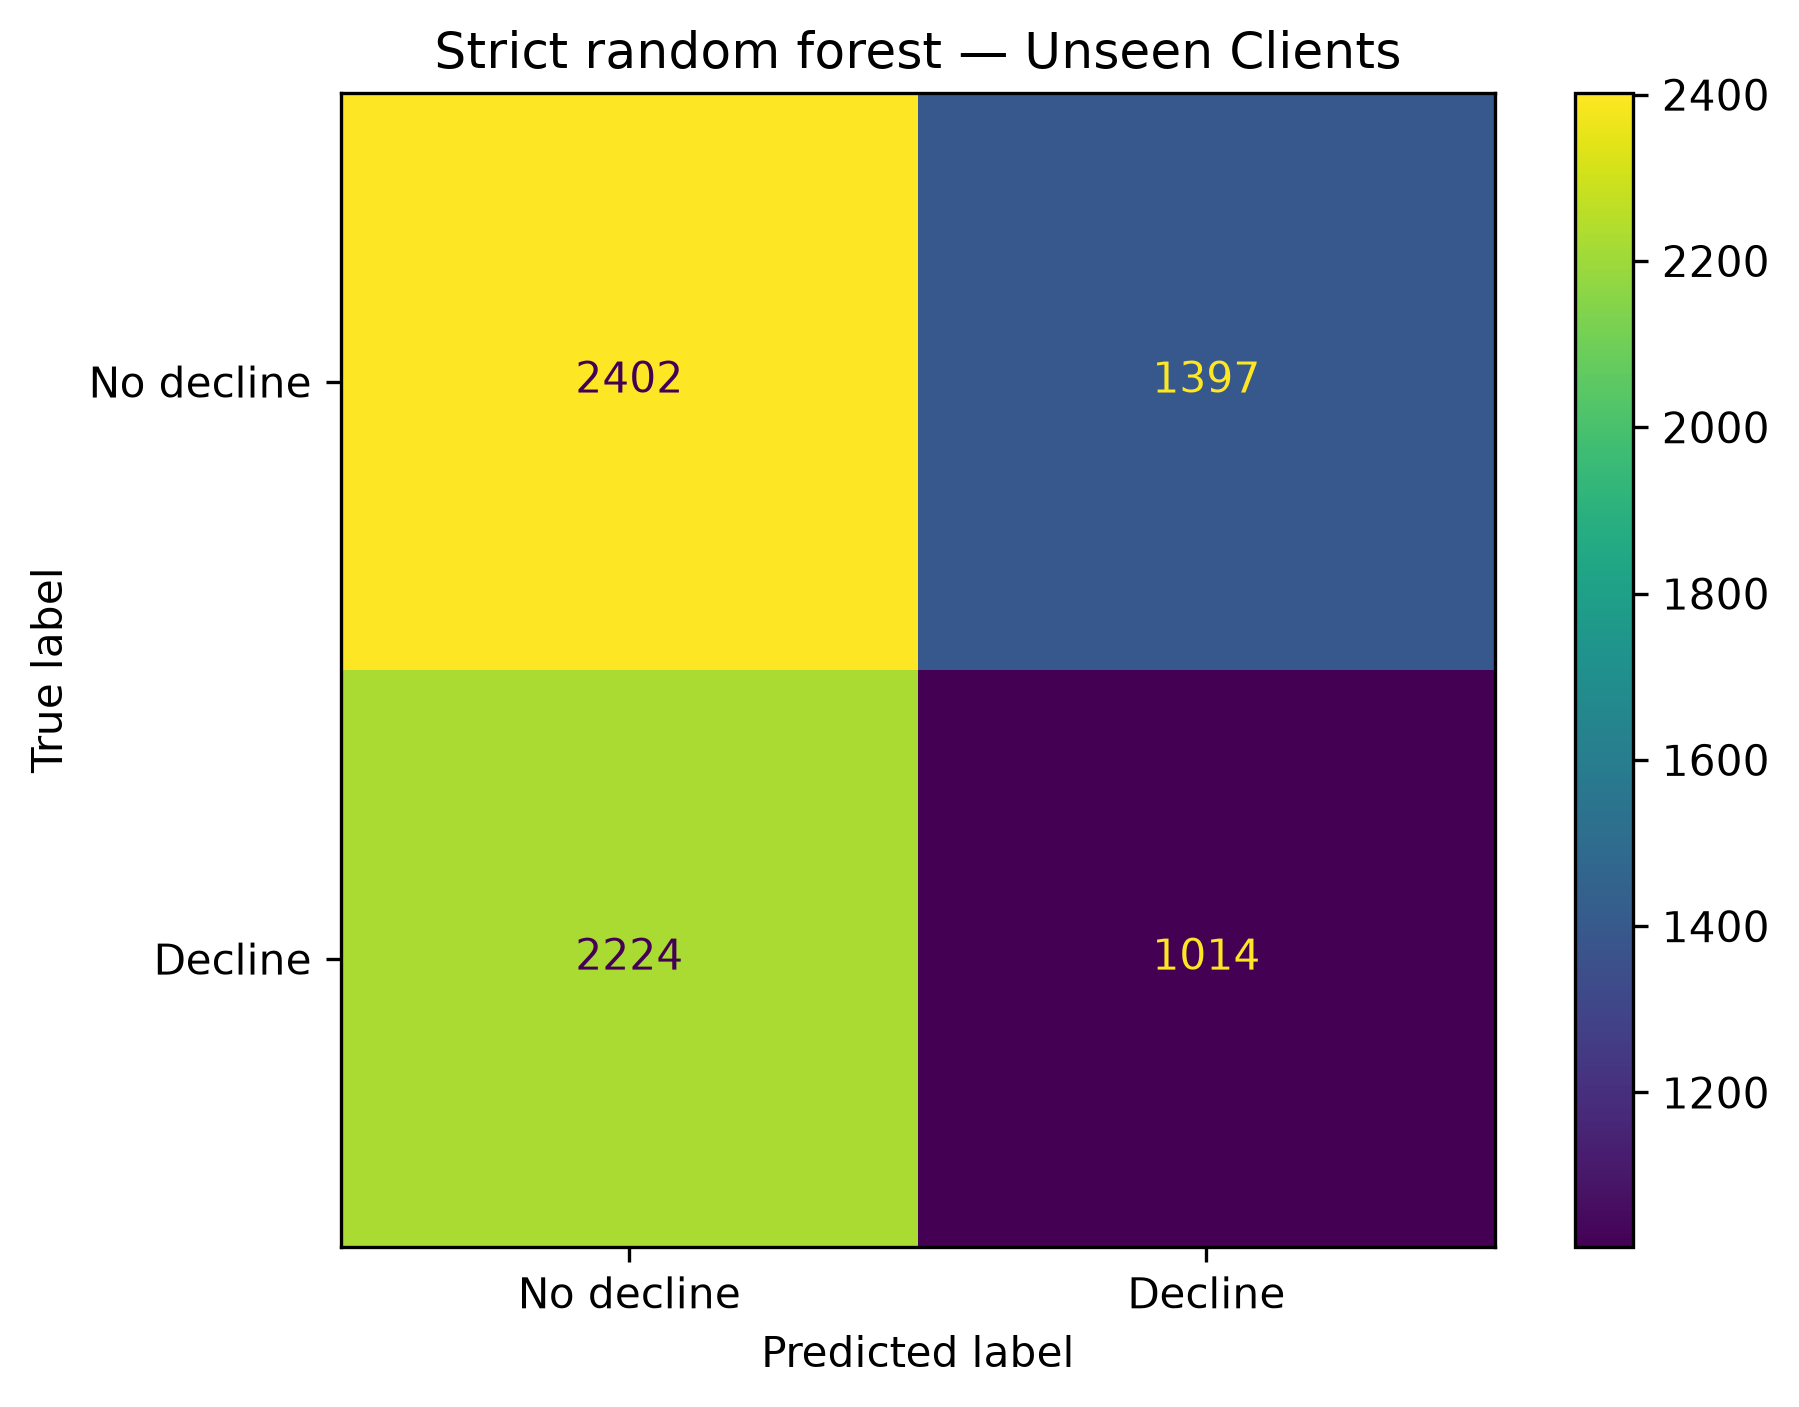

### Strict random forest feature importance

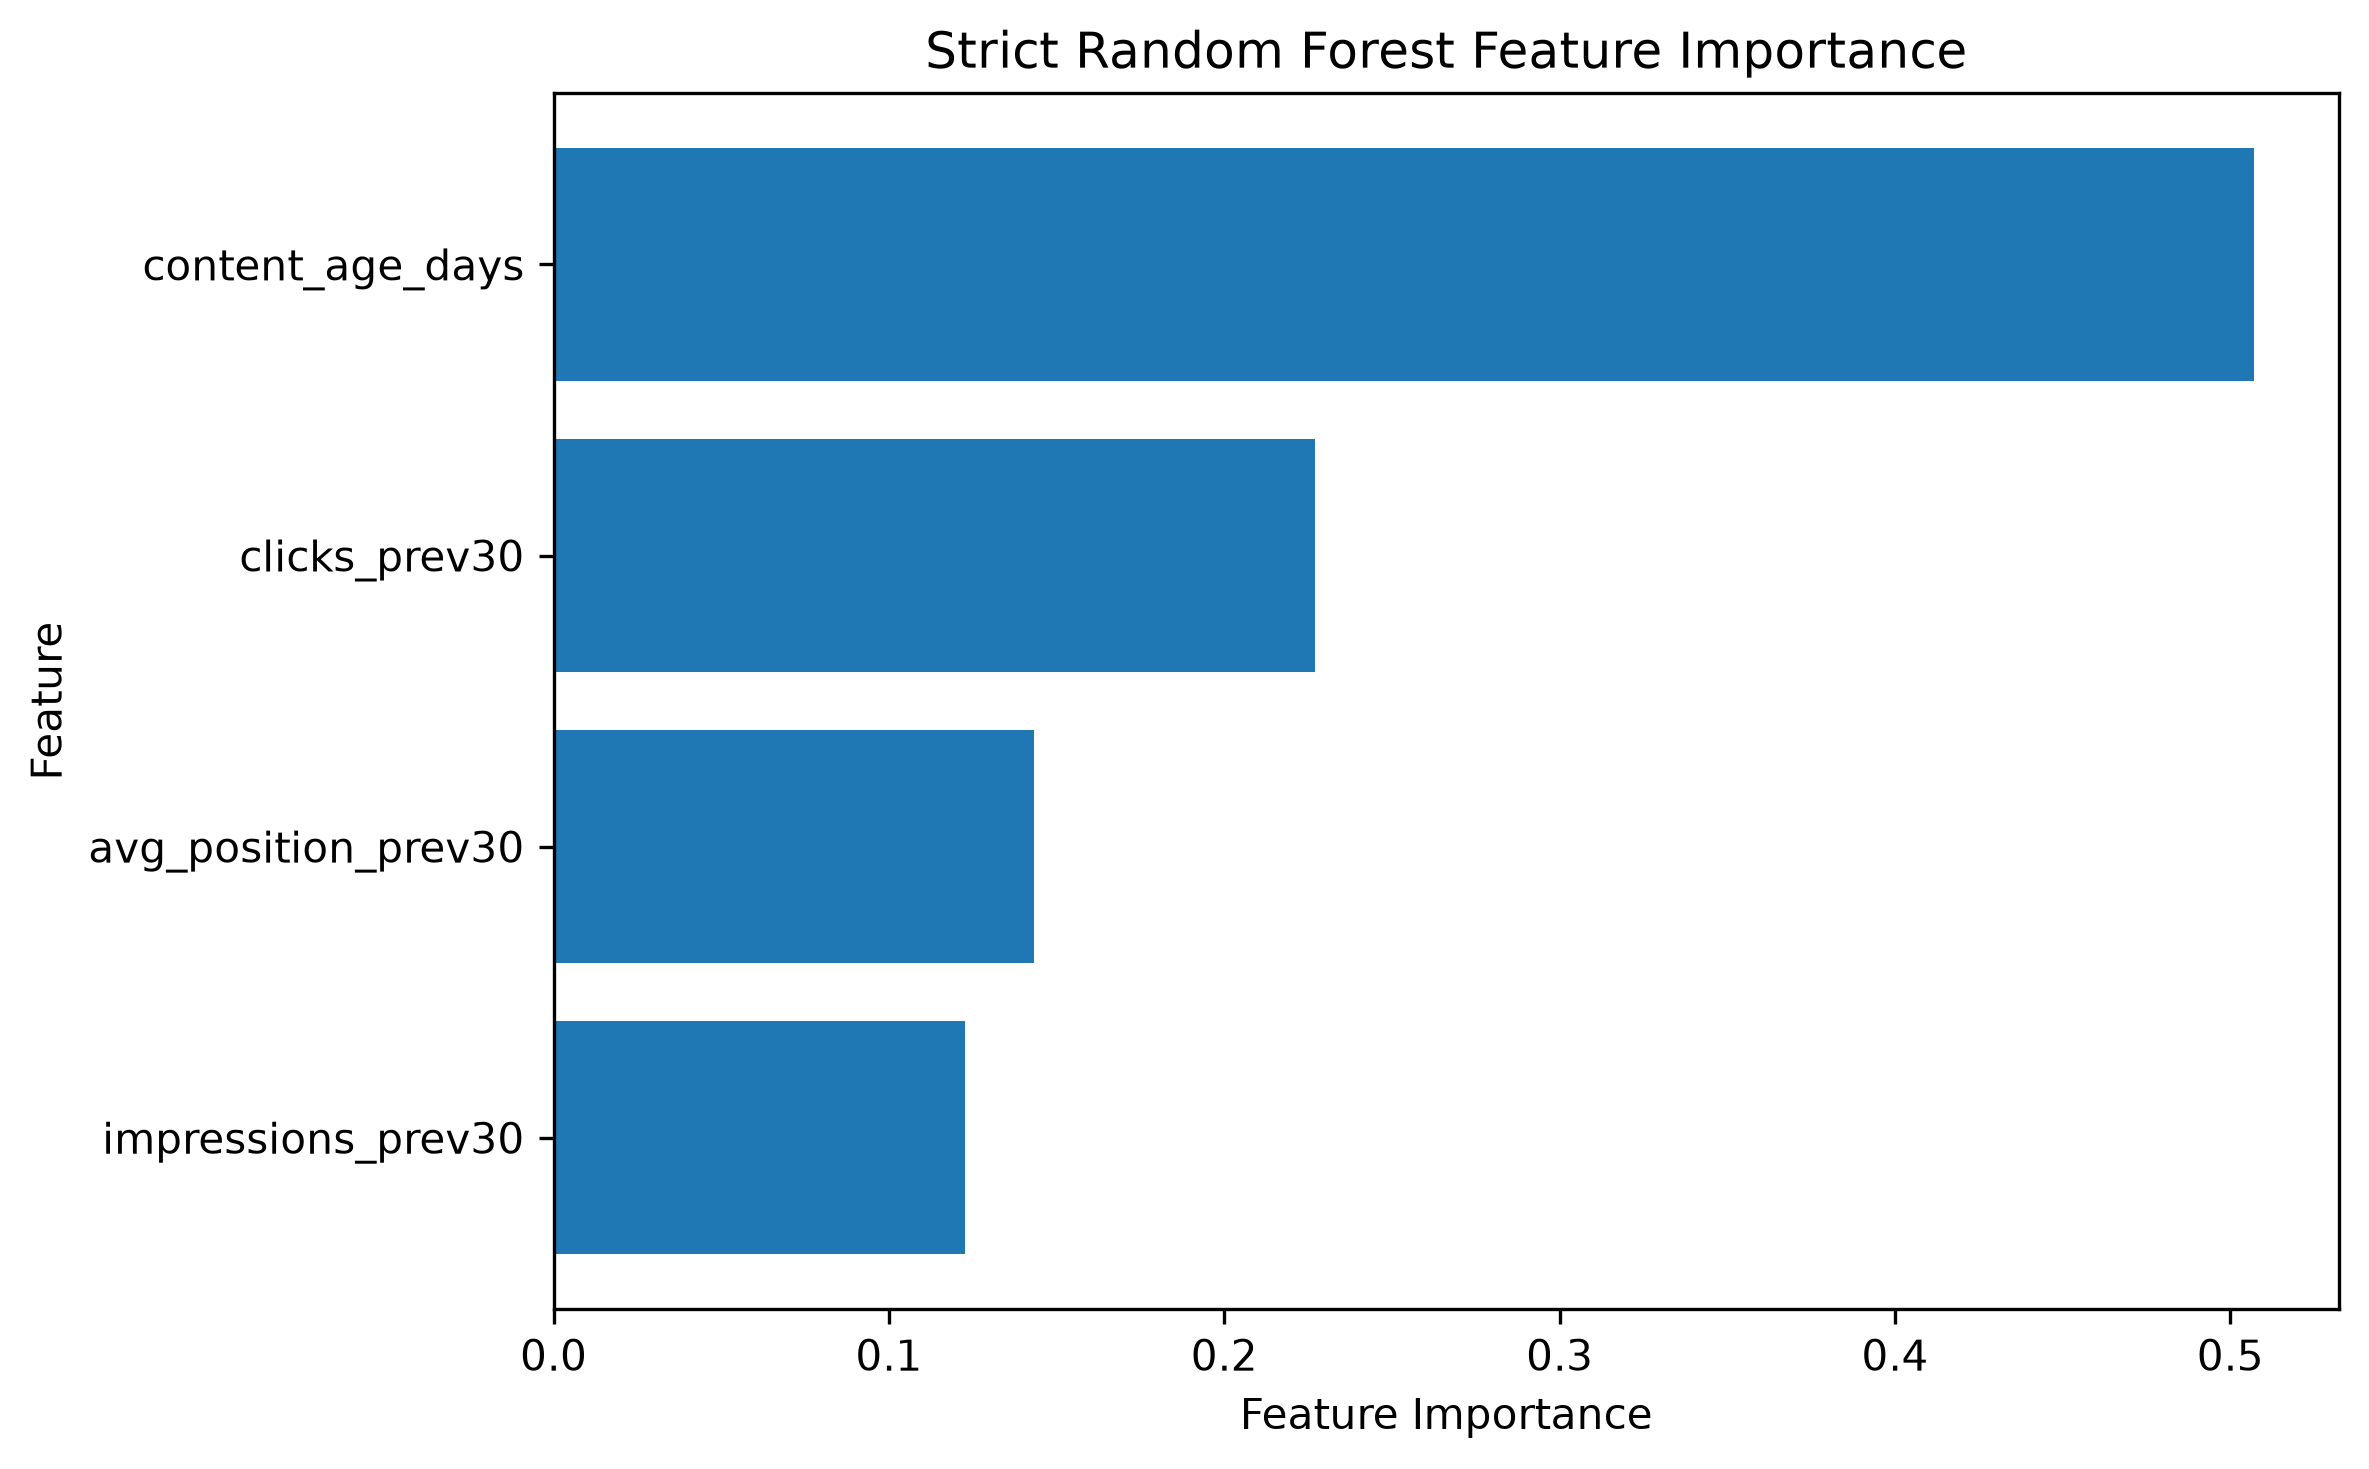

Paper-ready artifacts displayed


In [34]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown

outputs_dir = Path("../../work/outputs")
figures_dir = outputs_dir / "figures"

# Reload the saved final results
results_path = outputs_dir / "capstone_model_comparison.csv"
final_results_df = pd.read_csv(results_path)

display(Markdown("### Final model comparison"))
display(final_results_df.round(4))

paper_figures = [
    (
        "ROC curves on unseen clients",
        figures_dir / "capstone_roc_unseen_clients.png"
    ),
    (
        "Transparent baseline confusion matrix",
        figures_dir / "capstone_confusion_baseline.png"
    ),
    (
        "Strict logistic regression confusion matrix",
        figures_dir / "capstone_confusion_logistic.png"
    ),
    (
        "Strict random forest confusion matrix",
        figures_dir / "capstone_confusion_random_forest.png"
    ),
    (
        "Strict random forest feature importance",
        figures_dir / "capstone_random_forest_feature_importance.png"
    )
]

for title, path in paper_figures:
    display(Markdown(f"### {title}"))

    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("Missing file:", path.resolve())

print("Paper-ready artifacts displayed")

---

# Communicating the Capstone

## Five-Minute Demo Outline

### 0:00–0:40 — Business problem

Content teams manage more pages than they can manually inspect. The objective of this project is to identify pages that are likely to experience a substantial decline in organic-search impressions, allowing analysts to prioritize their limited review capacity.

The model is designed as a screening and ranking tool. It does not automatically decide that a page should be refreshed.

### 0:40–1:20 — Prediction task

The task predicts whether a page will experience more than a 30% decline in Google Search Console impressions during the next non-overlapping 30-day period.

The feature window covers March 3 to April 1, 2026, while the outcome window covers April 2 to May 1, 2026. Pages required available GSC data and at least 100 impressions during the feature period.

### 1:20–2:00 — Leakage prevention and features

To preserve temporal validity, only information available at the prediction cutoff was used:

- Previous 30-day impressions
- Previous 30-day clicks
- Previous 30-day average position
- Content age at the cutoff date

Current-snapshot metadata whose historical values could not be verified was excluded because it could introduce temporal leakage.

### 2:00–2:40 — Validation design

The dataset contained 101,362 pages from 44 clients.

Instead of randomly splitting individual pages, clients were used as groups. The final test set therefore contained 7,037 pages belonging to nine clients that were entirely absent from model training.

This provides a more realistic estimate of performance when the system encounters a previously unseen client.

### 2:40–3:40 — Model results

Three approaches were evaluated on the unseen-client test set:

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Transparent baseline | 0.5232 | 0.4908 | 0.9645 | 0.6506 | 0.6787 |
| Logistic regression | 0.4687 | 0.4510 | 0.7125 | 0.5524 | 0.4667 |
| Random forest | 0.4854 | 0.4206 | 0.3132 | 0.3590 | 0.5264 |

The transparent baseline produced the strongest ROC-AUC, F1 score, and recall. The more complex models did not improve generalization to unseen clients.

### 3:40–4:25 — Recommended use

The recommended approach is to rank eligible pages using the transparent baseline and send the highest-risk pages to a human analyst.

Its high recall is useful for screening because it captures most pages that later decline. However, its lower precision means that the flagged pages should be treated as review candidates rather than guaranteed refresh opportunities.

Analysts should combine the score with business value, strategic importance, conversion potential, and their own content assessment.

### 4:25–5:00 — Limitations and next steps

The analysis uses one historical feature-and-outcome period, so performance may vary across seasons and future client cohorts. The available leakage-safe feature set is intentionally small, and the results are predictive rather than causal.

The next step would be rolling time-window validation, probability calibration, threshold selection based on analyst capacity, and outcome tracking after human review.

---

## Social-Post Cut

I completed my FlyRank machine-learning capstone on predicting organic-search impression decline.

I built a leakage-aware evaluation pipeline using 101,362 pages from 44 clients and tested the models on nine completely unseen clients. Rather than using a random page split, I grouped the data by client to better represent real deployment conditions.

The most important result was that the transparent baseline outperformed logistic regression and random forest on unseen-client ROC-AUC and F1. This was a useful reminder that a more complex model is not automatically a better production decision.

The final system is framed as decision support: rank pages by risk, let analysts review the highest-priority candidates, and never treat a model prediction as an automatic instruction to refresh content.

Key tools: Python, pandas, DuckDB, scikit-learn, Hugging Face datasets, matplotlib, grouped validation, and temporal leakage analysis.

---

## Employer-Facing Summary

I developed an end-to-end machine-learning workflow that predicts substantial organic-search impression decline using temporally valid features and evaluates performance on clients excluded entirely from training. I compared a transparent baseline, logistic regression, and random forest across 101,362 pages, documented leakage risks, produced reproducible metrics and figures, and translated the results into a human-review prioritization workflow. The project demonstrates practical skills in problem framing, SQL-based data preparation, feature engineering, grouped validation, model evaluation, reproducibility, and responsible communication of model limitations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
